# Partie III — RNN, LSTM, GRU et Seq2Seq sur textes footballistiques

**Projet Deep Learning EMSI — FootAI**  
Notebook autonome consacré aux séquences et à la génération de texte.

## Objectif de la partie

Construire un corpus textuel footballistique à partir des événements **StatsBomb Open Data**, puis :

1. comparer **RNN simple**, **LSTM** et **GRU** pour une classification de phrases ;
2. construire un mini système **Seq2Seq encodeur-décodeur** pour générer des commentaires courts ;
3. comparer le décodage **greedy** et le **beam search** avec un BLEU simplifié.

## Plan du notebook

1. Installation, imports et fonctions communes.
2. Chargement StatsBomb.
3. Construction d'un corpus de phrases.
4. Tokenisation, vocabulaire, padding et mini-lots.
5. RNN / LSTM / GRU pour classification.
6. Gradient clipping.
7. Seq2Seq GRU avec teacher forcing.
8. Greedy decoding, beam search et BLEU simplifié.
9. Analyse critique et synthèse.


## Rappels théoriques essentiels

Un modèle de langage cherche à modéliser la probabilité d'une séquence de tokens :

```text
P(w1, w2, ..., wT) = P(w1) × P(w2|w1) × ... × P(wT|w1, ..., wT-1)
```

Les modèles récurrents traitent les tokens dans l'ordre. Le **RNN simple** peut souffrir de gradients instables. Les **LSTM** et **GRU** utilisent des mécanismes de portes pour mieux conserver l'information utile. Le **BPTT** correspond à la rétropropagation à travers le temps. Le **gradient clipping** limite les gradients explosifs.

La perplexité mesure la difficulté du modèle à prédire une séquence : plus elle est faible, meilleur est le modèle de langage. Dans ce notebook, l'évaluation principale du Seq2Seq est faite avec un **BLEU simplifié**, car la tâche est une génération courte de commentaire.


In [1]:
# ============================================================
# 0. Installation minimale
# ============================================================

import sys, subprocess, importlib.util

def pip_install(package):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Colab possède déjà torch/torchvision dans la majorité des cas.
required = {
    "requests": "requests",
    "yaml": "pyyaml",
    "sklearn": "scikit-learn",
    "PIL": "pillow",
    "tqdm": "tqdm",
    "roboflow": "roboflow",
}

for import_name, package_name in required.items():
    if importlib.util.find_spec(import_name) is None:
        pip_install(package_name)

print("Installations vérifiées.")


Installations vérifiées.


In [2]:
# ============================================================
# 0. Imports et configuration générale
# ============================================================

import os
import re
import math
import json
import random
import shutil
import zipfile
import requests
import warnings
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, random_split
from torchvision import transforms, datasets

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report

warnings.filterwarnings("ignore")

PROJECT_DIR = Path("/content/FootAI_Partie3_RNN_Seq2Seq")
DATA_DIR = PROJECT_DIR / "data"
OUTPUT_DIR = PROJECT_DIR / "outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
FIG_DIR = OUTPUT_DIR / "figures"

for p in [DATA_DIR, OUTPUT_DIR, CHECKPOINT_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device utilisé :", DEVICE)


Device utilisé : cuda


In [3]:
# ============================================================
# 0. Fonctions communes
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)


def compute_classification_metrics(y_true, y_pred, labels=None):
    acc = accuracy_score(y_true, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_confusion_matrix_simple(y_true, y_pred, class_names, title="Matrice de confusion", save_name=None):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_title(title)
    ax.set_xlabel("Prédiction")
    ax.set_ylabel("Vraie classe")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()


def plot_training_curves(history, title="Courbes d'entraînement", save_name=None):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(history.get("train_loss", []), label="train loss")
    ax.plot(history.get("val_loss", []), label="val loss")
    ax.set_title(title)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True)
    fig.tight_layout()
    if save_name:
        fig.savefig(FIG_DIR / save_name, dpi=150, bbox_inches="tight")
    plt.show()

    if "train_acc" in history and "val_acc" in history:
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(history["train_acc"], label="train accuracy")
        ax.plot(history["val_acc"], label="val accuracy")
        ax.set_title(title + " - Accuracy")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("Accuracy")
        ax.legend()
        ax.grid(True)
        fig.tight_layout()
        if save_name:
            fig.savefig(FIG_DIR / ("acc_" + save_name), dpi=150, bbox_inches="tight")
        plt.show()


def save_checkpoint(model, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)


def load_checkpoint(model, path, device=DEVICE):
    model.load_state_dict(torch.load(path, map_location=device))
    return model


def train_classifier(model, train_loader, val_loader, epochs=8, lr=1e-3, device=DEVICE, clip_norm=None):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_f1 = -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, train_true, train_pred = [], [], []

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()

            train_losses.append(loss.item())
            preds = logits.argmax(dim=1).detach().cpu().numpy()
            train_pred.extend(preds)
            train_true.extend(yb.detach().cpu().numpy())

        val_loss, val_metrics, _, _ = evaluate_classifier(model, val_loader, device=device, return_preds=True)
        train_metrics = compute_classification_metrics(train_true, train_pred)

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} | val_loss={val_loss:.4f} | val_f1={val_metrics['f1']:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_state


@torch.no_grad()
def evaluate_classifier(model, loader, device=DEVICE, return_preds=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses, y_true, y_pred = [], [], []

    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        preds = logits.argmax(dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(yb.cpu().numpy())

    metrics = compute_classification_metrics(y_true, y_pred)
    mean_loss = float(np.mean(losses)) if losses else 0.0

    if return_preds:
        return mean_loss, metrics, np.array(y_true), np.array(y_pred)
    return mean_loss, metrics


## Vérification rapide

Cette cellule confirme que le notebook utilise le bon dossier de travail et le bon device.


In [4]:

print("Projet :", PROJECT_DIR)
print("Dossier outputs :", OUTPUT_DIR)
print("Device :", DEVICE)


Projet : /content/FootAI_Partie3_RNN_Seq2Seq
Dossier outputs : /content/FootAI_Partie3_RNN_Seq2Seq/outputs
Device : cuda


# Chargement StatsBomb Open Data

Cette cellule rend la Partie III indépendante de la Partie I. Elle recharge les événements StatsBomb nécessaires à la construction du corpus textuel.


In [5]:
# ============================================================
# 1. Chargement StatsBomb Open Data sans authentification
# ============================================================

STATS_BOMB_BASE = "https://raw.githubusercontent.com/statsbomb/open-data/master/data"


def fetch_json(url):
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()


def choose_available_competition():
    # Choisit automatiquement une compétition disponible dans l'open data.
    competitions = fetch_json(f"{STATS_BOMB_BASE}/competitions.json")
    comp_df = pd.DataFrame(competitions)

    # Quelques compétitions StatsBomb connues. Si l'une échoue, on cherche une autre compétition.
    preferred = [
        (43, 106),  # Coupe du monde 2022 si disponible
        (43, 3),    # Coupe du monde 2018
        (72, 30),   # Women's World Cup 2019
        (11, 90),
        (16, 4),
    ]

    available_pairs = set(zip(comp_df["competition_id"], comp_df["season_id"]))
    for pair in preferred:
        if pair in available_pairs:
            return pair

    first = comp_df.iloc[0]
    return int(first["competition_id"]), int(first["season_id"])


def load_statsbomb_events(max_matches=12):
    competition_id, season_id = choose_available_competition()
    print(f"Compétition choisie : competition_id={competition_id}, season_id={season_id}")

    matches_url = f"{STATS_BOMB_BASE}/matches/{competition_id}/{season_id}.json"
    matches = fetch_json(matches_url)
    matches_df = pd.DataFrame(matches)
    matches_df = matches_df.head(max_matches).copy()
    print("Nombre de matchs chargés :", len(matches_df))

    all_events = []
    for match_id in tqdm(matches_df["match_id"], desc="Chargement événements"):
        events_url = f"{STATS_BOMB_BASE}/events/{match_id}.json"
        raw_events = fetch_json(events_url)
        df = pd.json_normalize(raw_events, sep="_")
        df["match_id"] = match_id
        all_events.append(df)

    events_df = pd.concat(all_events, ignore_index=True)
    print("Nombre total d'événements :", len(events_df))
    return events_df, matches_df


events_df_all, matches_df = load_statsbomb_events(max_matches=12)
events_df_all.head()

Compétition choisie : competition_id=43, season_id=106
Nombre de matchs chargés : 12


Chargement événements:   0%|          | 0/12 [00:00<?, ?it/s]

Nombre total d'événements : 43613


,id,index,period,timestamp,minute,second,possession,duration,type_id,type_name,...,ball_recovery_offensive,pass_straight,pass_no_touch,shot_redirect,goalkeeper_punched_out,bad_behaviour_card_id,bad_behaviour_card_name,block_save_block,shot_saved_off_target,goalkeeper_shot_saved_off_target
0,1f60fe1e-0340-49e2-975e-f16f54c5da1a,1,1,00:00:00.000,0,0,1,0.00000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,d5ffdab0-a19a-497e-a0f6-d5403bfcc2b5,2,1,00:00:00.000,0,0,1,0.00000,35,Starting XI,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,c6dcab53-5a07-4a6e-ab8b-64e9f9133d19,3,1,00:00:00.000,0,0,1,0.00000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,396c6ebb-5ba7-415c-ba37-88ff51f7c737,4,1,00:00:00.000,0,0,1,0.00000,18,Half Start,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,05a57281-9295-408a-9c4f-e32d7fad4d96,5,1,00:00:00.460,0,0,2,0.83469,30,Pass,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Partie III — RNN, LSTM, GRU et Seq2Seq sur textes footballistiques

## Objectif

On construit un corpus footballistique à partir des événements StatsBomb.

Deux tâches sont gardées :

1. **Classification de texte :** reconnaître le type d'action décrit par une phrase.
2. **Génération Seq2Seq :** transformer une description structurée en commentaire footballistique naturel.


In [6]:
# ============================================================
# 3. Construction d'un corpus footballistique à partir de StatsBomb
# ============================================================

ACTION_TYPES = ["Shot", "Pass", "Carry", "Dribble", "Duel", "Goal Keeper"]


def safe_get(row, col, default=""):
    val = row[col] if col in row.index else default
    if pd.isna(val):
        return default
    return str(val)


def event_to_sentence_and_label(row):
    t = safe_get(row, "type_name", "Action")
    player = safe_get(row, "player_name", "le joueur") or "le joueur"
    team = safe_get(row, "team_name", "son équipe") or "son équipe"

    if t == "Shot":
        body = safe_get(row, "shot_body_part_name", "")
        outcome = safe_get(row, "shot_outcome_name", "")
        sent = f"{player} tente un tir {body} pour {team} et le résultat est {outcome}"
        label = "tir"
    elif t == "Pass":
        height = safe_get(row, "pass_height_name", "")
        outcome = safe_get(row, "pass_outcome_name", "réussie") or "réussie"
        sent = f"{player} réalise une passe {height} pour {team} avec issue {outcome}"
        label = "passe"
    elif t == "Carry":
        sent = f"{player} progresse balle au pied pour faire avancer {team}"
        label = "conduite"
    elif t == "Dribble":
        outcome = safe_get(row, "dribble_outcome_name", "")
        sent = f"{player} tente un dribble et le résultat est {outcome}"
        label = "dribble"
    elif t == "Duel":
        outcome = safe_get(row, "duel_outcome_name", "")
        sent = f"{player} dispute un duel face à son adversaire avec issue {outcome}"
        label = "duel"
    elif t == "Goal Keeper":
        outcome = safe_get(row, "goalkeeper_outcome_name", "")
        sent = f"le gardien intervient dans la surface et le résultat est {outcome}"
        label = "gardien"
    else:
        sent = f"{player} réalise une action de football pour {team}"
        label = "autre"

    sent = re.sub(r"\s+", " ", sent).strip().lower()
    return sent, label


def build_text_classification_dataset(events_df, max_examples=2500):
    df = events_df[events_df["type_name"].isin(ACTION_TYPES)].copy()
    df = df.sample(frac=1, random_state=42).head(max_examples)
    rows = []
    for _, row in df.iterrows():
        sent, label = event_to_sentence_and_label(row)
        rows.append({"text": sent, "label": label})
    out = pd.DataFrame(rows)
    return out


text_df = build_text_classification_dataset(events_df_all, max_examples=2500)
print(text_df["label"].value_counts())
text_df.head()

label
passe       1286
conduite    1050
duel          77
dribble       40
gardien       26
tir           21
Name: count, dtype: int64


,text,label
0,morteza pouraliganji réalise une passe ground ...,passe
1,thomas meunier réalise une passe ground pass p...,passe
2,mattéo guendouzi olié progresse balle au pied ...,conduite
3,raheem sterling progresse balle au pied pour f...,conduite
4,declan rice réalise une passe low pass pour en...,passe


In [7]:
# ============================================================
# 3. Tokenisation, vocabulaire, Dataset texte
# ============================================================

PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"
SOS_TOKEN = "<SOS>"
EOS_TOKEN = "<EOS>"


def tokenize(text):
    return re.findall(r"[a-zA-ZÀ-ÿ0-9']+", str(text).lower())


def build_vocab(texts, min_freq=1, specials=[PAD_TOKEN, UNK_TOKEN, SOS_TOKEN, EOS_TOKEN]):
    counter = Counter()
    for text in texts:
        counter.update(tokenize(text))
    vocab = list(specials)
    for tok, freq in counter.items():
        if freq >= min_freq and tok not in vocab:
            vocab.append(tok)
    stoi = {tok: i for i, tok in enumerate(vocab)}
    itos = {i: tok for tok, i in stoi.items()}
    return stoi, itos


def encode_tokens(tokens, stoi, add_sos_eos=False):
    ids = []
    if add_sos_eos:
        ids.append(stoi[SOS_TOKEN])
    ids.extend([stoi.get(tok, stoi[UNK_TOKEN]) for tok in tokens])
    if add_sos_eos:
        ids.append(stoi[EOS_TOKEN])
    return ids


class FootballTextDataset(Dataset):
    def __init__(self, df, text_stoi, label_stoi):
        self.texts = df["text"].tolist()
        self.labels = [label_stoi[x] for x in df["label"].tolist()]
        self.text_stoi = text_stoi

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        tokens = tokenize(self.texts[idx])
        ids = encode_tokens(tokens, self.text_stoi, add_sos_eos=False)
        return torch.tensor(ids, dtype=torch.long), torch.tensor(self.labels[idx], dtype=torch.long)


def collate_text_classification(batch):
    seqs, labels = zip(*batch)
    lengths = torch.tensor([len(s) for s in seqs], dtype=torch.long)
    max_len = max(lengths).item()
    padded = torch.full((len(seqs), max_len), fill_value=text_stoi[PAD_TOKEN], dtype=torch.long)
    for i, seq in enumerate(seqs):
        padded[i, :len(seq)] = seq
    labels = torch.stack(labels)
    return padded, lengths, labels


# Split texte
train_text_df, temp_text_df = train_test_split(text_df, test_size=0.30, random_state=42, stratify=text_df["label"])
val_text_df, test_text_df = train_test_split(temp_text_df, test_size=0.50, random_state=42, stratify=temp_text_df["label"])

text_stoi, text_itos = build_vocab(train_text_df["text"].tolist(), min_freq=1)
labels_sorted = sorted(text_df["label"].unique())
label_stoi = {label: i for i, label in enumerate(labels_sorted)}
label_itos = {i: label for label, i in label_stoi.items()}

train_text_ds = FootballTextDataset(train_text_df, text_stoi, label_stoi)
val_text_ds = FootballTextDataset(val_text_df, text_stoi, label_stoi)
test_text_ds = FootballTextDataset(test_text_df, text_stoi, label_stoi)

train_loader_text = DataLoader(train_text_ds, batch_size=32, shuffle=True, collate_fn=collate_text_classification)
val_loader_text = DataLoader(val_text_ds, batch_size=64, shuffle=False, collate_fn=collate_text_classification)
test_loader_text = DataLoader(test_text_ds, batch_size=64, shuffle=False, collate_fn=collate_text_classification)

print("Taille vocabulaire :", len(text_stoi))
print("Labels :", label_stoi)

Taille vocabulaire : 614
Labels : {'conduite': 0, 'dribble': 1, 'duel': 2, 'gardien': 3, 'passe': 4, 'tir': 5}


In [8]:
# ============================================================
# 3. Modèles RNN / LSTM / GRU pour classification
# ============================================================

class TextRNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim, rnn_type="GRU", pad_idx=0, dropout=0.2):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.rnn_type = rnn_type.upper()

        if self.rnn_type == "RNN":
            self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
        elif self.rnn_type == "LSTM":
            self.rnn = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        elif self.rnn_type == "GRU":
            self.rnn = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        else:
            raise ValueError("rnn_type doit être RNN, LSTM ou GRU")

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, lengths):
        emb = self.embedding(x)
        packed = nn.utils.rnn.pack_padded_sequence(
            emb, lengths.cpu(), batch_first=True, enforce_sorted=False
        )
        _, hidden = self.rnn(packed)
        if self.rnn_type == "LSTM":
            hidden = hidden[0]
        last_hidden = hidden[-1]
        return self.fc(self.dropout(last_hidden))


def train_text_classifier(model, train_loader, val_loader, epochs=6, lr=1e-3, clip_norm=1.0, device=DEVICE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state, best_f1 = None, -1

    for epoch in range(1, epochs + 1):
        model.train()
        train_losses, y_true, y_pred = [], [], []
        grad_norms = []

        for xb, lengths, yb in train_loader:
            xb, lengths, yb = xb.to(device), lengths.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb, lengths)
            loss = criterion(logits, yb)
            loss.backward()

            if clip_norm is not None:
                total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
                grad_norms.append(float(total_norm))

            optimizer.step()
            train_losses.append(loss.item())
            y_true.extend(yb.cpu().numpy())
            y_pred.extend(logits.argmax(dim=1).detach().cpu().numpy())

        val_loss, val_metrics, _, _ = evaluate_text_classifier(model, val_loader, device=device, return_preds=True)
        train_metrics = compute_classification_metrics(y_true, y_pred)
        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])

        if val_metrics["f1"] > best_f1:
            best_f1 = val_metrics["f1"]
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        grad_msg = f" | grad_norm_moy={np.mean(grad_norms):.2f}" if grad_norms else ""
        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} | val_f1={val_metrics['f1']:.4f}{grad_msg}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_state


@torch.no_grad()
def evaluate_text_classifier(model, loader, device=DEVICE, return_preds=False):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    losses, y_true, y_pred = [], [], []
    for xb, lengths, yb in loader:
        xb, lengths, yb = xb.to(device), lengths.to(device), yb.to(device)
        logits = model(xb, lengths)
        loss = criterion(logits, yb)
        losses.append(loss.item())
        y_true.extend(yb.cpu().numpy())
        y_pred.extend(logits.argmax(dim=1).cpu().numpy())
    metrics = compute_classification_metrics(y_true, y_pred)
    mean_loss = float(np.mean(losses)) if losses else 0.0
    if return_preds:
        return mean_loss, metrics, np.array(y_true), np.array(y_pred)
    return mean_loss, metrics

In [9]:
# ============================================================
# 3. Comparaison RNN / LSTM / GRU
# ============================================================

sequence_results = []
sequence_models = {}

for rnn_type in ["RNN", "LSTM", "GRU"]:
    print("\n" + "="*70)
    print("Modèle :", rnn_type)
    model = TextRNNClassifier(
        vocab_size=len(text_stoi),
        embed_dim=64,
        hidden_dim=128,
        output_dim=len(label_stoi),
        rnn_type=rnn_type,
        pad_idx=text_stoi[PAD_TOKEN],
    )
    history, best_state = train_text_classifier(
        model, train_loader_text, val_loader_text, epochs=6, lr=1e-3, clip_norm=1.0, device=DEVICE
    )
    if best_state is not None:
        model.load_state_dict(best_state)

    test_loss, test_metrics, y_true_txt, y_pred_txt = evaluate_text_classifier(model, test_loader_text, device=DEVICE, return_preds=True)
    row = {"model": rnn_type, "test_loss": test_loss, **test_metrics}
    sequence_results.append(row)
    sequence_models[rnn_type] = model
    print("Résultats test :", row)

sequence_results_df = pd.DataFrame(sequence_results).sort_values("f1", ascending=False)
sequence_results_df.to_csv(OUTPUT_DIR / "partie3_rnn_lstm_gru_resultats.csv", index=False)
sequence_results_df


Modèle : RNN
Epoch 01/6 | train_loss=0.2578 | val_f1=0.9824 | grad_norm_moy=0.70
Epoch 02/6 | train_loss=0.0246 | val_f1=0.9973 | grad_norm_moy=0.14
Epoch 03/6 | train_loss=0.0112 | val_f1=0.9973 | grad_norm_moy=0.08
Epoch 04/6 | train_loss=0.0063 | val_f1=0.9973 | grad_norm_moy=0.05
Epoch 05/6 | train_loss=0.0035 | val_f1=1.0000 | grad_norm_moy=0.03
Epoch 06/6 | train_loss=0.0020 | val_f1=1.0000 | grad_norm_moy=0.02
Résultats test : {'model': 'RNN', 'test_loss': 0.0028730042395181954, 'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'f1': 1.0}

Modèle : LSTM
Epoch 01/6 | train_loss=0.4834 | val_f1=0.9713 | grad_norm_moy=0.50
Epoch 02/6 | train_loss=0.0638 | val_f1=0.9946 | grad_norm_moy=0.09
Epoch 03/6 | train_loss=0.0253 | val_f1=1.0000 | grad_norm_moy=0.07
Epoch 04/6 | train_loss=0.0078 | val_f1=1.0000 | grad_norm_moy=0.04
Epoch 05/6 | train_loss=0.0026 | val_f1=1.0000 | grad_norm_moy=0.01
Epoch 06/6 | train_loss=0.0015 | val_f1=1.0000 | grad_norm_moy=0.01
Résultats test : {'model

,model,test_loss,accuracy,precision,recall,f1
0,RNN,0.002873,1.0,1.0,1.0,1.0
1,LSTM,0.014337,1.0,1.0,1.0,1.0
2,GRU,0.016888,1.0,1.0,1.0,1.0


Meilleur modèle texte : RNN


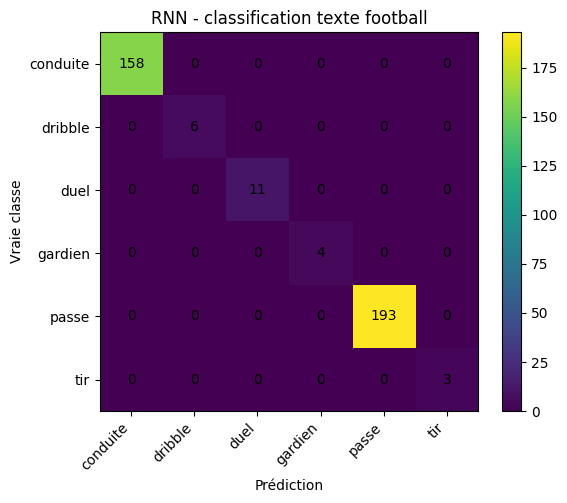

              precision    recall  f1-score   support

    conduite       1.00      1.00      1.00       158
     dribble       1.00      1.00      1.00         6
        duel       1.00      1.00      1.00        11
     gardien       1.00      1.00      1.00         4
       passe       1.00      1.00      1.00       193
         tir       1.00      1.00      1.00         3

    accuracy                           1.00       375
   macro avg       1.00      1.00      1.00       375
weighted avg       1.00      1.00      1.00       375



In [10]:
# ============================================================
# 3. Matrice de confusion du meilleur modèle séquentiel
# ============================================================

best_seq_name = sequence_results_df.iloc[0]["model"]
best_seq_model = sequence_models[best_seq_name]
print("Meilleur modèle texte :", best_seq_name)

_, _, y_true_txt, y_pred_txt = evaluate_text_classifier(best_seq_model, test_loader_text, device=DEVICE, return_preds=True)
plot_confusion_matrix_simple(
    y_true_txt,
    y_pred_txt,
    [label_itos[i] for i in range(len(label_itos))],
    f"{best_seq_name} - classification texte football",
    "text_sequence_confusion_matrix.png",
)

print(classification_report(y_true_txt, y_pred_txt, target_names=[label_itos[i] for i in range(len(label_itos))], zero_division=0))

## Seq2Seq — Génération de commentaires footballistiques

On simplifie la génération : le modèle reçoit une séquence structurée comme :

```text
shot right_foot goal
```

et doit générer un commentaire naturel :

```text
le joueur marque un but du pied droit
```

Cela permet de garder l'architecture encodeur-décodeur, le teacher forcing, le greedy decoding, le beam search et BLEU, sans faire un modèle énorme.


In [11]:
# ============================================================
# 3. Création des paires Seq2Seq à partir de StatsBomb
# ============================================================

def normalize_token(x):
    x = str(x).lower().strip()
    x = re.sub(r"[^a-z0-9à-ÿ]+", "_", x)
    x = re.sub(r"_+", "_", x).strip("_")
    return x or "unknown"


def event_to_seq2seq_pair(row):
    t = safe_get(row, "type_name", "Action")

    if t == "Shot":
        body = normalize_token(safe_get(row, "shot_body_part_name", "foot"))
        outcome = normalize_token(safe_get(row, "shot_outcome_name", "unknown"))
        src = f"shot {body} {outcome}"
        if "goal" in outcome:
            tgt = f"le joueur marque un but avec {body}"
        elif "saved" in outcome:
            tgt = f"le joueur tente un tir avec {body} mais le gardien arrête le ballon"
        else:
            tgt = f"le joueur tente un tir avec {body} et le résultat est {outcome}"

    elif t == "Pass":
        height = normalize_token(safe_get(row, "pass_height_name", "pass"))
        outcome = normalize_token(safe_get(row, "pass_outcome_name", "successful"))
        src = f"pass {height} {outcome}"
        if outcome == "successful" or outcome == "unknown":
            tgt = f"le joueur réussit une passe {height}"
        else:
            tgt = f"le joueur tente une passe {height} mais le résultat est {outcome}"

    elif t == "Dribble":
        outcome = normalize_token(safe_get(row, "dribble_outcome_name", "unknown"))
        src = f"dribble {outcome}"
        tgt = f"le joueur tente un dribble et le résultat est {outcome}"

    elif t == "Carry":
        src = "carry progressive"
        tgt = "le joueur progresse balle au pied vers la zone adverse"

    elif t == "Duel":
        outcome = normalize_token(safe_get(row, "duel_outcome_name", "unknown"))
        src = f"duel {outcome}"
        tgt = f"le joueur dispute un duel et le résultat est {outcome}"

    else:
        return None

    src = src.lower().strip()
    tgt = re.sub(r"\s+", " ", tgt.lower()).strip()
    return src, tgt


def build_seq2seq_pairs(events_df, max_pairs=1500):
    rows = []
    df = events_df[events_df["type_name"].isin(["Shot", "Pass", "Carry", "Dribble", "Duel"])].sample(frac=1, random_state=42)
    for _, row in df.iterrows():
        pair = event_to_seq2seq_pair(row)
        if pair is not None:
            rows.append(pair)
        if len(rows) >= max_pairs:
            break
    return pd.DataFrame(rows, columns=["src", "tgt"])


seq2seq_df = build_seq2seq_pairs(events_df_all, max_pairs=1500)
seq2seq_df.head(10)

,src,tgt
0,pass ground_pass incomplete,le joueur tente une passe ground_pass mais le ...
1,pass ground_pass successful,le joueur réussit une passe ground_pass
2,carry progressive,le joueur progresse balle au pied vers la zone...
3,dribble complete,le joueur tente un dribble et le résultat est ...
4,carry progressive,le joueur progresse balle au pied vers la zone...
5,pass high_pass successful,le joueur réussit une passe high_pass
6,carry progressive,le joueur progresse balle au pied vers la zone...
7,carry progressive,le joueur progresse balle au pied vers la zone...
8,carry progressive,le joueur progresse balle au pied vers la zone...
9,pass ground_pass successful,le joueur réussit une passe ground_pass


In [12]:
# ============================================================
# 3. Dataset Seq2Seq
# ============================================================

src_train, src_temp = train_test_split(seq2seq_df, test_size=0.25, random_state=42)
src_val, src_test = train_test_split(src_temp, test_size=0.50, random_state=42)

src_stoi, src_itos = build_vocab(src_train["src"].tolist(), min_freq=1)
tgt_stoi, tgt_itos = build_vocab(src_train["tgt"].tolist(), min_freq=1)

class Seq2SeqFootballDataset(Dataset):
    def __init__(self, df, src_stoi, tgt_stoi):
        self.src = df["src"].tolist()
        self.tgt = df["tgt"].tolist()
        self.src_stoi = src_stoi
        self.tgt_stoi = tgt_stoi

    def __len__(self):
        return len(self.src)

    def __getitem__(self, idx):
        src_ids = encode_tokens(tokenize(self.src[idx]), self.src_stoi, add_sos_eos=True)
        tgt_ids = encode_tokens(tokenize(self.tgt[idx]), self.tgt_stoi, add_sos_eos=True)
        return torch.tensor(src_ids, dtype=torch.long), torch.tensor(tgt_ids, dtype=torch.long)


def collate_seq2seq(batch):
    srcs, tgts = zip(*batch)
    src_lengths = torch.tensor([len(s) for s in srcs], dtype=torch.long)
    tgt_lengths = torch.tensor([len(t) for t in tgts], dtype=torch.long)
    max_src = max(src_lengths).item()
    max_tgt = max(tgt_lengths).item()

    src_pad = torch.full((len(srcs), max_src), src_stoi[PAD_TOKEN], dtype=torch.long)
    tgt_pad = torch.full((len(tgts), max_tgt), tgt_stoi[PAD_TOKEN], dtype=torch.long)

    for i, s in enumerate(srcs):
        src_pad[i, :len(s)] = s
    for i, t in enumerate(tgts):
        tgt_pad[i, :len(t)] = t

    return src_pad, src_lengths, tgt_pad, tgt_lengths


train_seq_ds = Seq2SeqFootballDataset(src_train, src_stoi, tgt_stoi)
val_seq_ds = Seq2SeqFootballDataset(src_val, src_stoi, tgt_stoi)
test_seq_ds = Seq2SeqFootballDataset(src_test, src_stoi, tgt_stoi)

train_loader_seq = DataLoader(train_seq_ds, batch_size=32, shuffle=True, collate_fn=collate_seq2seq)
val_loader_seq = DataLoader(val_seq_ds, batch_size=64, shuffle=False, collate_fn=collate_seq2seq)
test_loader_seq = DataLoader(test_seq_ds, batch_size=64, shuffle=False, collate_fn=collate_seq2seq)

print("Vocab source :", len(src_stoi))
print("Vocab cible :", len(tgt_stoi))
print("Nombre paires :", len(seq2seq_df))

Vocab source : 32
Vocab cible : 52
Nombre paires : 1500


In [13]:
# ============================================================
# 3. Modèle Seq2Seq GRU
# ============================================================

class EncoderGRU(nn.Module):
    def __init__(self, input_dim, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(input_dim, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)

    def forward(self, src, src_lengths):
        emb = self.embedding(src)
        packed = nn.utils.rnn.pack_padded_sequence(emb, src_lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, hidden = self.gru(packed)
        return hidden


class DecoderGRU(nn.Module):
    def __init__(self, output_dim, embed_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(output_dim, embed_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc_out = nn.Linear(hidden_dim, output_dim)

    def forward(self, input_token, hidden):
        # input_token: [batch]
        input_token = input_token.unsqueeze(1)
        emb = self.embedding(input_token)
        output, hidden = self.gru(emb, hidden)
        logits = self.fc_out(output.squeeze(1))
        return logits, hidden


class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, tgt_sos_idx, teacher_forcing_ratio=0.5):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.tgt_sos_idx = tgt_sos_idx
        self.teacher_forcing_ratio = teacher_forcing_ratio

    def forward(self, src, src_lengths, tgt):
        batch_size, tgt_len = tgt.shape
        vocab_size = self.decoder.fc_out.out_features
        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src.device)

        hidden = self.encoder(src, src_lengths)
        input_token = tgt[:, 0]

        for t in range(1, tgt_len):
            logits, hidden = self.decoder(input_token, hidden)
            outputs[:, t, :] = logits
            teacher_force = random.random() < self.teacher_forcing_ratio
            top1 = logits.argmax(dim=1)
            input_token = tgt[:, t] if teacher_force else top1

        return outputs

Epoch 01/8 | train_loss=2.6671 | val_loss=1.3043
Epoch 02/8 | train_loss=0.7865 | val_loss=0.4596
Epoch 03/8 | train_loss=0.3497 | val_loss=0.2669
Epoch 04/8 | train_loss=0.2222 | val_loss=0.1818
Epoch 05/8 | train_loss=0.1560 | val_loss=0.1463
Epoch 06/8 | train_loss=0.1246 | val_loss=0.1185
Epoch 07/8 | train_loss=0.1055 | val_loss=0.1066
Epoch 08/8 | train_loss=0.0875 | val_loss=0.0999


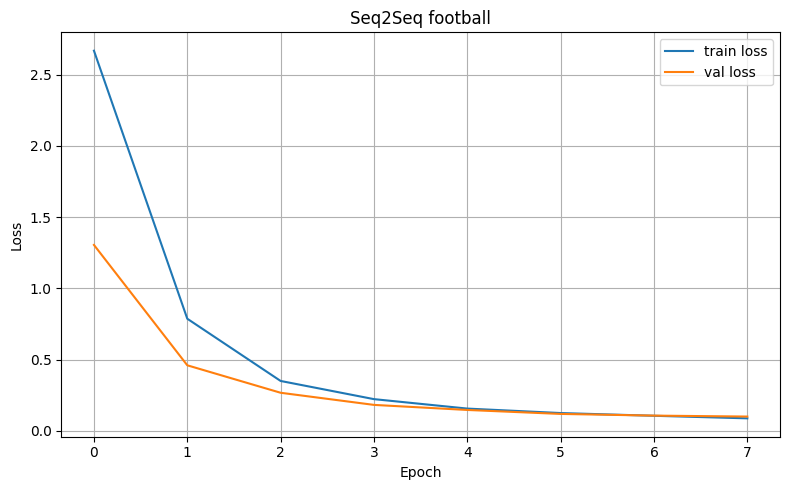

In [14]:
# ============================================================
# 3. Entraînement et évaluation Seq2Seq
# ============================================================

def train_seq2seq(model, train_loader, val_loader, epochs=8, lr=1e-3, clip_norm=1.0, device=DEVICE):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_stoi[PAD_TOKEN])
    history = {"train_loss": [], "val_loss": []}
    best_state, best_val = None, float("inf")

    for epoch in range(1, epochs + 1):
        model.train()
        losses = []
        for src, src_lengths, tgt, tgt_lengths in train_loader:
            src, src_lengths, tgt = src.to(device), src_lengths.to(device), tgt.to(device)
            optimizer.zero_grad()
            outputs = model(src, src_lengths, tgt)

            # On ignore la position 0 qui correspond à <SOS>
            logits = outputs[:, 1:, :].reshape(-1, outputs.shape[-1])
            target = tgt[:, 1:].reshape(-1)
            loss = criterion(logits, target)
            loss.backward()
            if clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_norm)
            optimizer.step()
            losses.append(loss.item())

        val_loss = evaluate_seq2seq_loss(model, val_loader, device=device)
        history["train_loss"].append(float(np.mean(losses)))
        history["val_loss"].append(val_loss)

        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch:02d}/{epochs} | train_loss={history['train_loss'][-1]:.4f} | val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)
    return history, best_state


@torch.no_grad()
def evaluate_seq2seq_loss(model, loader, device=DEVICE):
    model.eval()
    criterion = nn.CrossEntropyLoss(ignore_index=tgt_stoi[PAD_TOKEN])
    losses = []
    for src, src_lengths, tgt, tgt_lengths in loader:
        src, src_lengths, tgt = src.to(device), src_lengths.to(device), tgt.to(device)
        outputs = model(src, src_lengths, tgt)
        logits = outputs[:, 1:, :].reshape(-1, outputs.shape[-1])
        target = tgt[:, 1:].reshape(-1)
        loss = criterion(logits, target)
        losses.append(loss.item())
    return float(np.mean(losses)) if losses else 0.0


encoder = EncoderGRU(len(src_stoi), embed_dim=64, hidden_dim=128, pad_idx=src_stoi[PAD_TOKEN])
decoder = DecoderGRU(len(tgt_stoi), embed_dim=64, hidden_dim=128, pad_idx=tgt_stoi[PAD_TOKEN])
seq2seq_model = Seq2SeqGRU(encoder, decoder, tgt_sos_idx=tgt_stoi[SOS_TOKEN], teacher_forcing_ratio=0.5)

seq_history, seq_best_state = train_seq2seq(seq2seq_model, train_loader_seq, val_loader_seq, epochs=8, lr=1e-3, clip_norm=1.0, device=DEVICE)
plot_training_curves(seq_history, "Seq2Seq football", "seq2seq_training_curves.png")

In [15]:
# ============================================================
# 3. Greedy decoding, beam search et BLEU simplifié
# ============================================================

@torch.no_grad()
def greedy_decode(model, src_text, max_len=20, device=DEVICE):
    model.eval()
    src_ids = encode_tokens(tokenize(src_text), src_stoi, add_sos_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long).to(device)
    hidden = model.encoder(src_tensor, src_lengths)

    input_token = torch.tensor([tgt_stoi[SOS_TOKEN]], dtype=torch.long).to(device)
    out_tokens = []
    for _ in range(max_len):
        logits, hidden = model.decoder(input_token, hidden)
        next_token = logits.argmax(dim=1)
        tok_id = int(next_token.item())
        if tok_id == tgt_stoi[EOS_TOKEN]:
            break
        out_tokens.append(tgt_itos.get(tok_id, UNK_TOKEN))
        input_token = next_token
    return " ".join(out_tokens)


@torch.no_grad()
def beam_search_decode(model, src_text, beam_width=3, max_len=20, device=DEVICE):
    model.eval()
    src_ids = encode_tokens(tokenize(src_text), src_stoi, add_sos_eos=True)
    src_tensor = torch.tensor(src_ids, dtype=torch.long).unsqueeze(0).to(device)
    src_lengths = torch.tensor([len(src_ids)], dtype=torch.long).to(device)
    hidden0 = model.encoder(src_tensor, src_lengths)

    beams = [([tgt_stoi[SOS_TOKEN]], hidden0, 0.0)]

    for _ in range(max_len):
        new_beams = []
        for tokens_ids, hidden, score in beams:
            last_id = tokens_ids[-1]
            if last_id == tgt_stoi[EOS_TOKEN]:
                new_beams.append((tokens_ids, hidden, score))
                continue

            input_token = torch.tensor([last_id], dtype=torch.long).to(device)
            logits, new_hidden = model.decoder(input_token, hidden)
            log_probs = F.log_softmax(logits, dim=1)
            top_scores, top_ids = torch.topk(log_probs, beam_width, dim=1)

            for s, idx in zip(top_scores[0], top_ids[0]):
                new_beams.append((tokens_ids + [int(idx.item())], new_hidden.clone(), score + float(s.item())))

        beams = sorted(new_beams, key=lambda x: x[2], reverse=True)[:beam_width]

    best_ids = beams[0][0]
    words = []
    for idx in best_ids:
        if idx in [tgt_stoi[SOS_TOKEN], tgt_stoi[PAD_TOKEN]]:
            continue
        if idx == tgt_stoi[EOS_TOKEN]:
            break
        words.append(tgt_itos.get(idx, UNK_TOKEN))
    return " ".join(words)


def simple_bleu_score(reference, hypothesis, max_n=2):
    ref_tokens = tokenize(reference)
    hyp_tokens = tokenize(hypothesis)
    if len(hyp_tokens) == 0:
        return 0.0

    precisions = []
    for n in range(1, max_n + 1):
        ref_ngrams = Counter(tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens)-n+1))
        hyp_ngrams = Counter(tuple(hyp_tokens[i:i+n]) for i in range(len(hyp_tokens)-n+1))
        overlap = sum((hyp_ngrams & ref_ngrams).values())
        total = max(sum(hyp_ngrams.values()), 1)
        precisions.append((overlap + 1e-8) / total)

    geo_mean = math.exp(sum(math.log(p) for p in precisions) / max_n)
    bp = 1.0 if len(hyp_tokens) > len(ref_tokens) else math.exp(1 - len(ref_tokens) / max(len(hyp_tokens), 1))
    return float(bp * geo_mean)


# Quelques exemples
sample_df = src_test.head(10).copy()
rows = []
for _, row in sample_df.iterrows():
    src = row["src"]
    ref = row["tgt"]
    greedy = greedy_decode(seq2seq_model, src)
    beam = beam_search_decode(seq2seq_model, src, beam_width=3)
    rows.append({
        "source": src,
        "reference": ref,
        "greedy": greedy,
        "beam": beam,
        "bleu_greedy": simple_bleu_score(ref, greedy),
        "bleu_beam": simple_bleu_score(ref, beam),
    })

seq2seq_examples_df = pd.DataFrame(rows)
seq2seq_examples_df.to_csv(OUTPUT_DIR / "partie3_seq2seq_exemples.csv", index=False)
seq2seq_examples_df

,source,reference,greedy,beam,bleu_greedy,bleu_beam
0,pass ground_pass successful,le joueur réussit une passe ground_pass,le joueur réussit une passe ground pass,le joueur réussit une passe ground pass,1.0,1.0
1,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
2,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
3,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
4,pass ground_pass successful,le joueur réussit une passe ground_pass,le joueur réussit une passe ground pass,le joueur réussit une passe ground pass,1.0,1.0
5,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
6,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
7,pass ground_pass successful,le joueur réussit une passe ground_pass,le joueur réussit une passe ground pass,le joueur réussit une passe ground pass,1.0,1.0
8,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0
9,carry progressive,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,le joueur progresse balle au pied vers la zone...,1.0,1.0


In [16]:
# ============================================================
# 3. Évaluation BLEU sur le test
# ============================================================

bleu_rows = []
for _, row in tqdm(src_test.head(200).iterrows(), total=min(200, len(src_test)), desc="BLEU test"):
    src = row["src"]
    ref = row["tgt"]
    greedy = greedy_decode(seq2seq_model, src)
    beam = beam_search_decode(seq2seq_model, src, beam_width=3)
    bleu_rows.append({
        "bleu_greedy": simple_bleu_score(ref, greedy),
        "bleu_beam": simple_bleu_score(ref, beam),
    })

bleu_df = pd.DataFrame(bleu_rows)
bleu_summary = bleu_df.mean().to_frame("score_moyen").reset_index().rename(columns={"index": "metric"})
bleu_summary.to_csv(OUTPUT_DIR / "partie3_seq2seq_bleu.csv", index=False)
bleu_summary

BLEU test:   0%|          | 0/188 [00:00<?, ?it/s]

,metric,score_moyen
0,bleu_greedy,0.973501
1,bleu_beam,0.970327


## Analyse critique — Partie III : RNN, LSTM, GRU et Seq2Seq

Après exécution du notebook de la Partie III, les résultats montrent que les modèles récurrents sont bien adaptés au traitement de séquences textuelles footballistiques.  
Le corpus a été construit à partir des événements réels **StatsBomb Open Data**, puis transformé en phrases simples décrivant des actions de match.

Deux tâches principales ont été réalisées :

1. **Classification de séquences footballistiques** avec RNN, LSTM et GRU.
2. **Génération de commentaires courts** avec un modèle Seq2Seq encodeur-décodeur.

Le corpus de classification contient **2 500 phrases**, réparties entre plusieurs classes : `passe`, `conduite`, `duel`, `dribble`, `gardien` et `tir`.  
Le vocabulaire de classification contient **614 tokens**.  
Pour la partie Seq2Seq, le corpus contient **1 500 paires source/cible**, avec un vocabulaire source de **32 tokens** et un vocabulaire cible de **52 tokens**.

---

### 1. RNN simple

Le RNN simple traite les tokens dans l’ordre grâce à un état caché transmis d’un pas de temps au suivant.  
Il permet donc de prendre en compte la structure séquentielle d’une phrase, contrairement à un MLP classique qui traiterait les tokens comme des caractéristiques indépendantes.

Dans cette expérience, le RNN obtient de très bons résultats sur la tâche de classification :

| Modèle | Accuracy | F1-score |
|---|---:|---:|
| RNN | 100 % | 100 % |

Ce résultat montre que le RNN simple est suffisant pour ce corpus, car les phrases sont courtes, régulières et très structurées. Par exemple, certains mots ou groupes de mots indiquent directement la classe de l’action : `passe`, `dribble`, `tir`, `gardien`, etc.

Cependant, cette performance ne signifie pas que le RNN simple est toujours le meilleur choix. Théoriquement, le RNN simple mémorise moins bien les dépendances longues. Lorsque les séquences deviennent plus longues ou plus ambiguës, il peut souffrir du problème de gradient évanescent et oublier des informations importantes situées au début de la phrase.

---

### 2. LSTM et GRU

Les LSTM et les GRU améliorent le RNN simple grâce à des mécanismes de portes.  
Ces portes contrôlent quelles informations doivent être conservées, oubliées ou mises à jour dans l’état caché.

Dans cette exécution, les trois modèles obtiennent des performances parfaites :

| Modèle | Accuracy | F1-score |
|---|---:|---:|
| RNN | 100 % | 100 % |
| LSTM | 100 % | 100 % |
| GRU | 100 % | 100 % |

Le LSTM et le GRU n’apportent donc pas d’amélioration visible sur cette tâche précise, car les phrases sont simples et les indices lexicaux sont très explicites.  
Cependant, leur intérêt reste important sur des séquences plus longues ou plus naturelles. Le LSTM possède une cellule mémoire qui permet de conserver l’information plus longtemps, tandis que le GRU propose une version plus légère avec moins de paramètres et une bonne stabilité.

Dans un corpus de commentaires humains plus riche, avec des phrases longues, des ambiguïtés et des dépendances à distance, le LSTM ou le GRU seraient probablement plus robustes que le RNN simple.

---

### 3. Gradient clipping

L’entraînement des modèles récurrents se fait par rétropropagation à travers le temps, appelée **BPTT**.  
Pendant cette rétropropagation, les gradients peuvent devenir très grands, surtout lorsque les séquences sont longues. Ce phénomène est appelé **gradient explosif**.

Pour limiter ce problème, le notebook utilise le **gradient clipping**. Cette technique limite la norme du gradient afin d’éviter des mises à jour trop brutales des paramètres.

Dans les résultats, les normes moyennes de gradient diminuent progressivement pendant l’entraînement. Par exemple, pour le RNN, la norme moyenne passe d’environ **0,70** à la première époque à environ **0,02** à la dernière époque. Cela montre que l’apprentissage devient stable au fil des époques.

Le gradient clipping est donc une sécurité importante. Même si le corpus utilisé ici est court et régulier, cette technique reste indispensable dans l’entraînement de modèles récurrents plus complexes.

---

### 4. Modèle Seq2Seq

Le modèle Seq2Seq est utilisé pour transformer une séquence source structurée en phrase cible plus naturelle.  
Par exemple, une entrée comme :

```text
pass ground_pass successful

## Question de synthèse — Partie III

**Réponse attendue dans le rapport :**

Les architectures récurrentes sont adaptées aux séquences car elles traitent les tokens dans l'ordre et produisent une représentation dépendante du contexte. Le RNN simple constitue une première solution, mais ses limites apparaissent lorsque la séquence devient plus longue ou lorsque les gradients deviennent instables. Les LSTM et GRU améliorent cette situation grâce à leurs mécanismes de portes. Pour une tâche de génération, le passage à un schéma encodeur-décodeur devient pertinent, car il transforme une séquence source en une séquence cible. La qualité de décodage dépend ensuite de la stratégie utilisée : greedy est rapide mais limité, tandis que beam search explore plusieurs phrases candidates.
